In [4]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
pd.set_option('display.max_columns',None)
sns.set_style('whitegrid')

In [7]:
df=pd.read_csv('../data/creditcard.csv')

In [8]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
df.shape

(284807, 31)

In [11]:
df.info()
#from the result it is clear that there is no null values in this data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [15]:
fraud_percentage=df['Class'].value_counts(normalize=True)
fraud_count=df['Class'].value_counts()
print(fraud_count)
print(f"\nFraud percentage: {fraud_percentage[1]:.4f}%")
print(f"Legit percentage: {fraud_percentage[0]:.4f}%")

Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.0017%
Legit percentage: 0.9983%


C:\Users\HP\AppData\Local\Temp\ipykernel_28976\3429251961.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class',data=df,palette=['steelblue','crimson'])


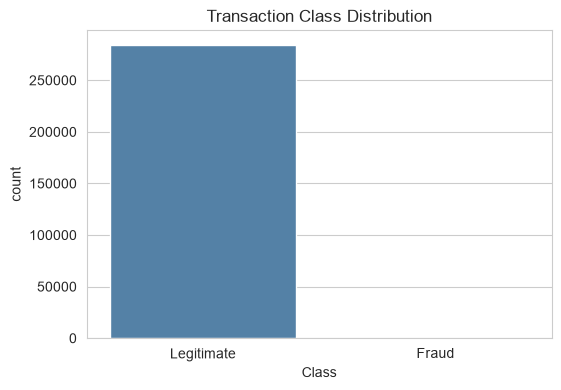

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class',data=df,palette=['steelblue','crimson'])
plt.xticks([0,1],['Legitimate','Fraud'])
plt.title('Transaction Class Distribution')
plt.ylabel('count')
plt.show()

In [19]:
#as we can see that only 492 are fraud out of the 284k transactions 
#so it will be a dumb model if we make it on the basis of accuracy score it will predict every transaction as legit transaction 
#This is why we use Precision ,Recall,F1 and PR-AUC instead.

In [21]:
print(df.columns.tolist())
df[['Time','Amount']].describe()

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


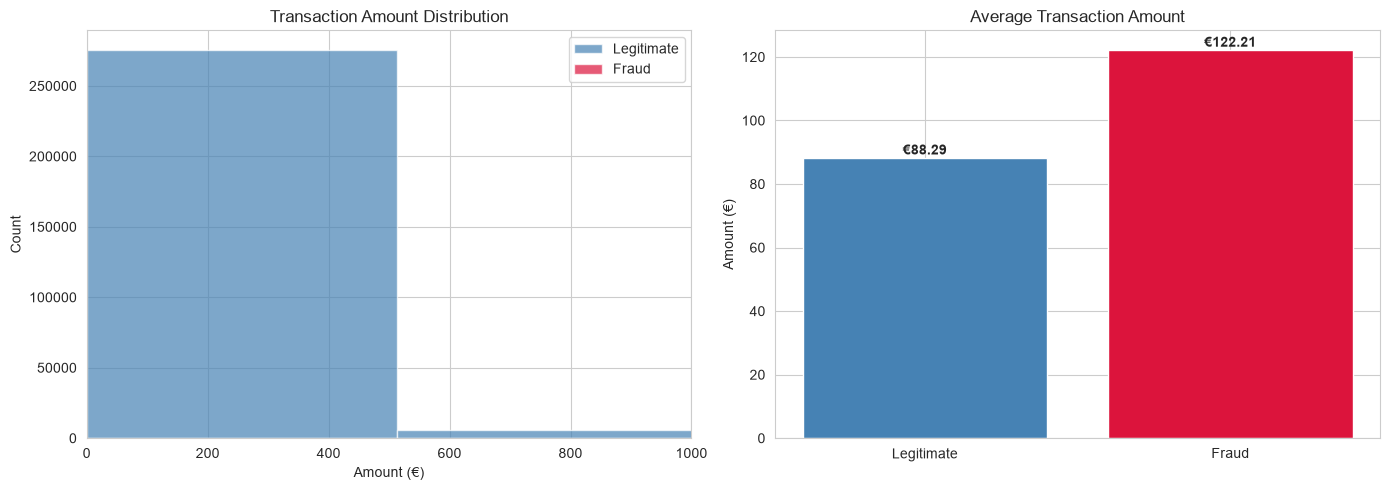

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Amount distribution
axes[0].hist(df[df['Class']==0]['Amount'], bins=50, 
            color='steelblue', alpha=0.7, label='Legitimate')
axes[0].hist(df[df['Class']==1]['Amount'], bins=50, 
            color='crimson', alpha=0.7, label='Fraud')
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount (€)')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 1000)  # zoom in, ignore extreme outliers
axes[0].legend()

# Average amount
avg_amounts = df.groupby('Class')['Amount'].mean()
axes[1].bar(['Legitimate', 'Fraud'], avg_amounts.values, 
            color=['steelblue', 'crimson'])
axes[1].set_title('Average Transaction Amount')
axes[1].set_ylabel('Amount (€)')
for i, v in enumerate(avg_amounts.values):
    axes[1].text(i, v + 1, f'€{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

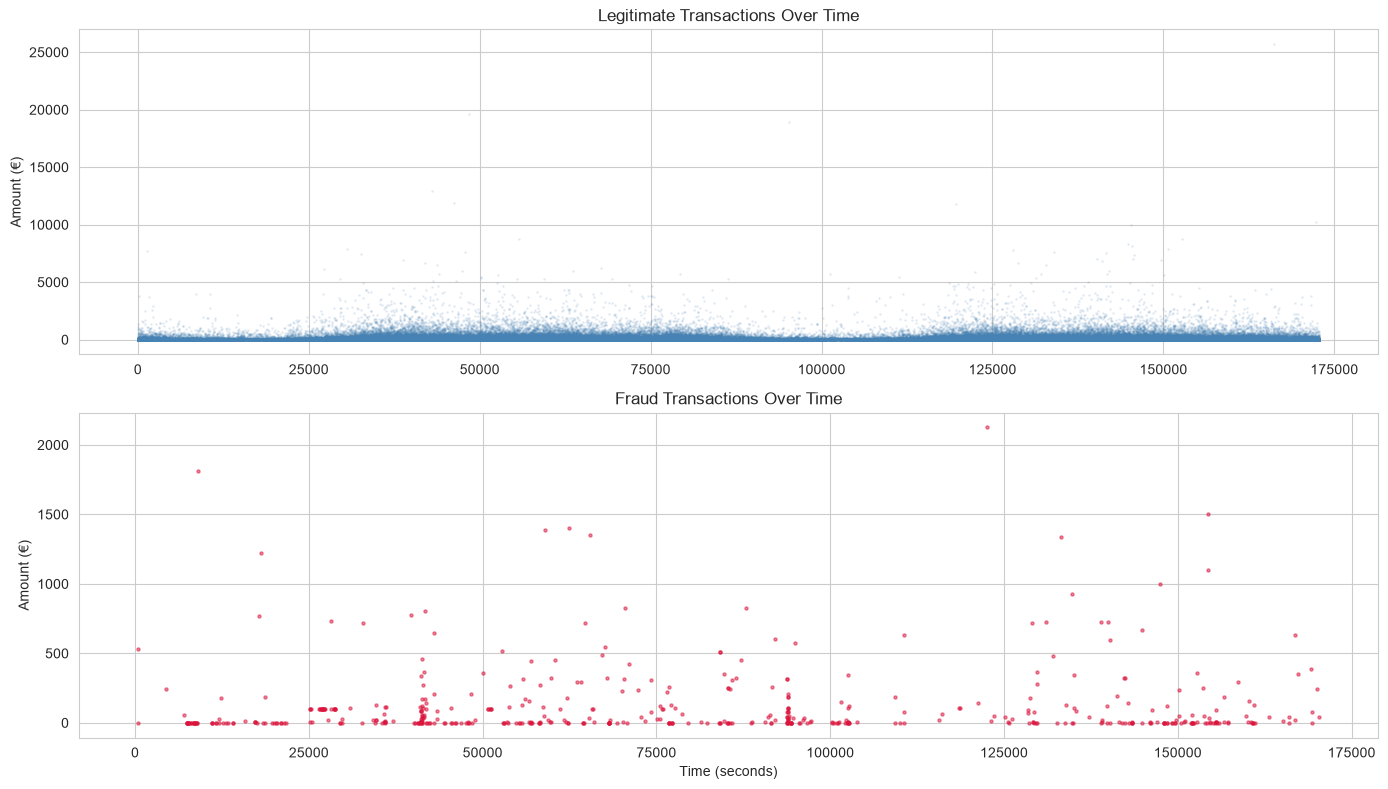

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Legitimate transactions over time
axes[0].scatter(df[df['Class']==0]['Time'], 
                df[df['Class']==0]['Amount'],
                alpha=0.1, s=1, color='steelblue')
axes[0].set_title('Legitimate Transactions Over Time')
axes[0].set_ylabel('Amount (€)')

# Fraud transactions over time
axes[1].scatter(df[df['Class']==1]['Time'], 
                df[df['Class']==1]['Amount'],
                alpha=0.5, s=5, color='crimson')
axes[1].set_title('Fraud Transactions Over Time')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Amount (€)')

plt.tight_layout()
plt.show()

In [34]:
correlations=df.corr()['Class'].drop('Class').sort_values(ascending=False)
print(correlations)

V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


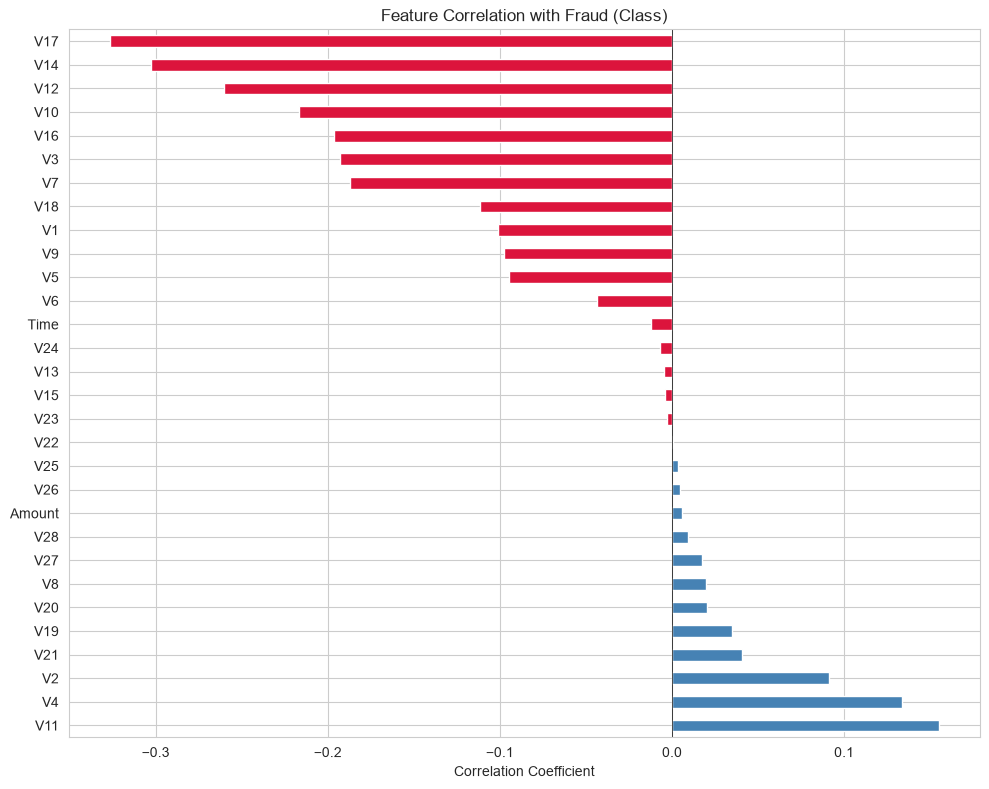

Top 5 features most correlated with fraud:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
Name: Class, dtype: float64


In [36]:
plt.figure(figsize=(10,8))
correlations.plot(kind='barh',color=['crimson' if x<0 else 'steelblue'
                                    for x in correlations])
plt.title('Feature Correlation with Fraud (Class)')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("Top 5 features most correlated with fraud:")
print(correlations.abs().sort_values(ascending=False).head())

In [ ]:
# Top 5 features most correlated with fraud:
# V17    0.326481
# V14    0.302544
# V12    0.260593
# V10    0.216883
# V16    0.196539


In [40]:
df[df['Class']==1]['Amount'].describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

<Axes: >

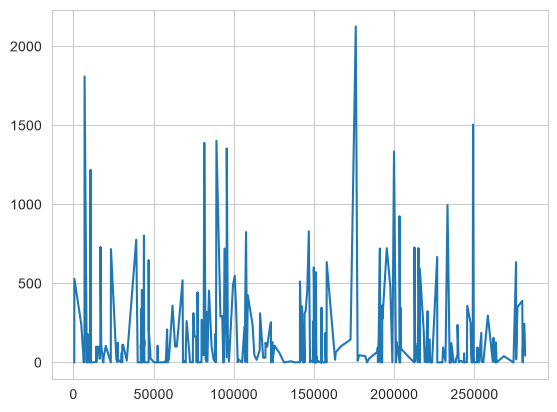

In [45]:
fraud_amount=df[df['Class']==1]['Amount']
fraud_amount.plot(kind='line')

In [41]:
df[df['Class']==0]['Amount'].describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

## EDA Key Findings

1. **Severe class imbalance** — only 0.17% fraud (492/284807)
   → Accuracy is meaningless. We optimize for F1 and PR-AUC.

2. **Fraud transactions tend to be smaller amounts** on average
   → Fraudsters avoid large transactions to stay under radar.

3. **V14, V17, V12, V10** show strongest negative correlation with fraud
   → These will likely be top SHAP features after training.

4. **No missing values** — dataset is clean, no imputation needed.

5. **Amount and Time need scaling** — V features are already PCA-scaled.
   → We apply StandardScaler to Amount and Time only.